In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from simlm.analysis import (
    load_and_process_results,
    plot_metric_distribution,
    plot_success_rate,
    plot_metric_by_difficulty,
    plot_iterations_histogram,
    print_summary_stats
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Configurations
RESULTS_DIR = Path("results") 
RESULT_FILE = RESULTS_DIR / "experiment_results-1260.jsonl" 
sns.set_theme(style="whitegrid")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 100 # Adjust plot resolution if needed

In [4]:
results_df = load_and_process_results(RESULT_FILE)

Loading results from: results\experiment_results-1260.jsonl
Processed 1259 valid results.


In [5]:
# Summary stats
print("\nOverview")
results_df.info()

print("\nCounts")
print("Strategies:\n", results_df['Strategy'].value_counts())
print("\nExperiment Conditions:\n", results_df['Experiment Condition'].value_counts())
print("\nLLM Models:\n", results_df['LLM Model Name'].value_counts())

print_summary_stats(results_df)


Overview
<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 0 to 1259
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     1259 non-null   datetime64[ns]
 1   Success                       1259 non-null   bool          
 2   Error                         1259 non-null   object        
 3   Time Taken (s)                833 non-null    float64       
 4   Iterations Run                1259 non-null   int32         
 5   Final Height (m)              833 non-null    float64       
 6   Final Velocity (m/s)          833 non-null    float64       
 7   Actual Distance Bounce 3 (m)  833 non-null    float64       
 8   Bounce Locations (m)          833 non-null    object        
 9   Strategy                      1259 non-null   object        
 10  Target Distance (m)           1259 non-null   float64       
 11  Max Iterations Allowed   

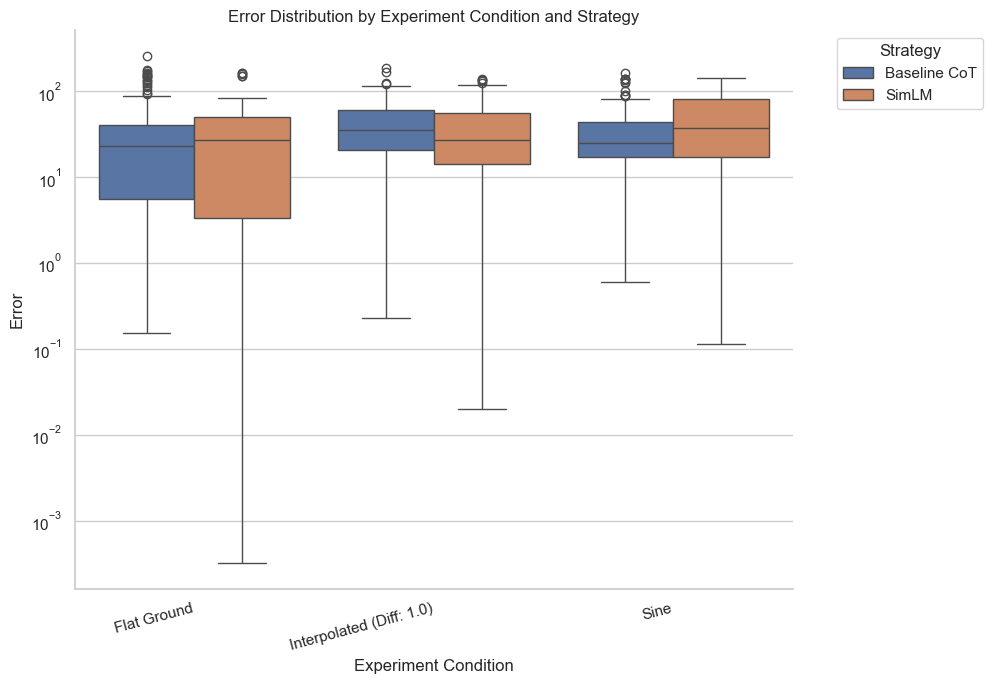

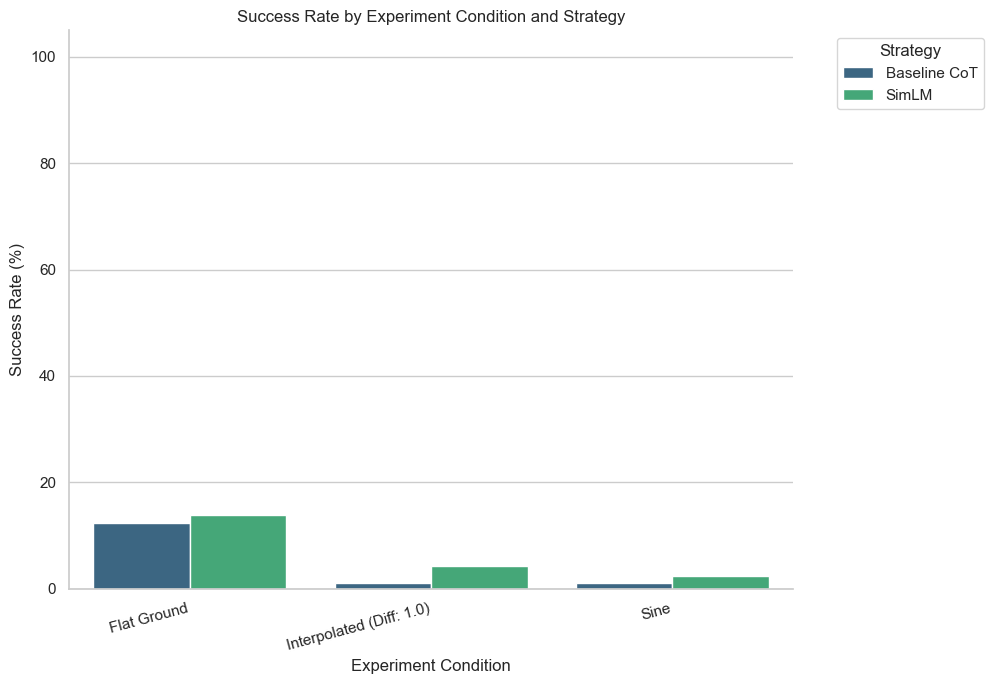

In [4]:
##### Strategy Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='Experiment Condition', 
    hue_col='Strategy',
    title='Error Distribution by Experiment Condition and Strategy',
    yscale='log' 
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Success Rate by Experiment Condition and Strategy'
)

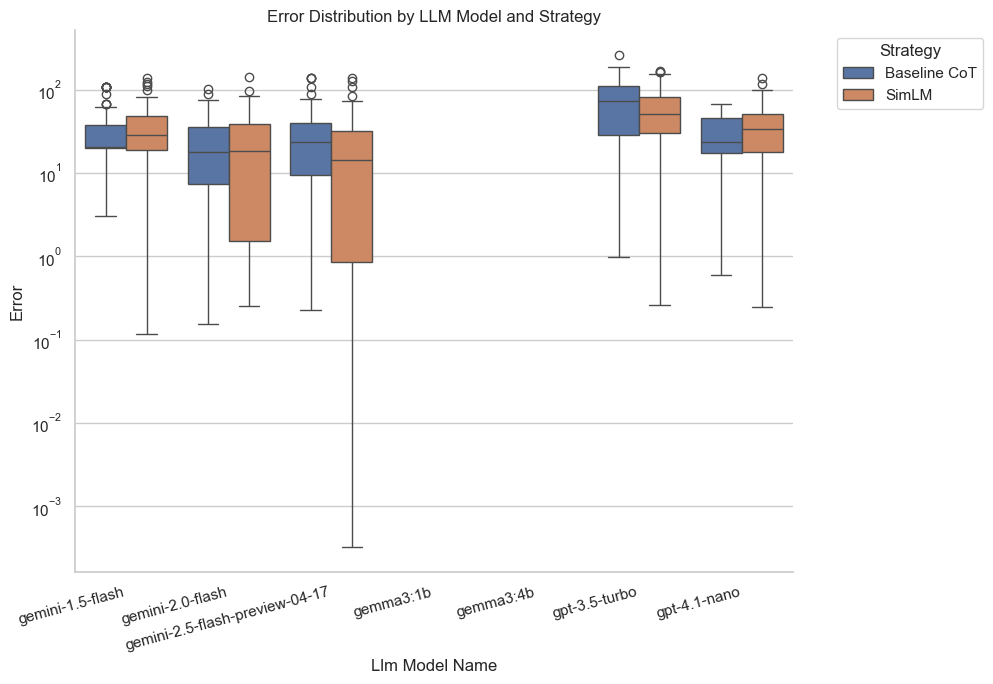

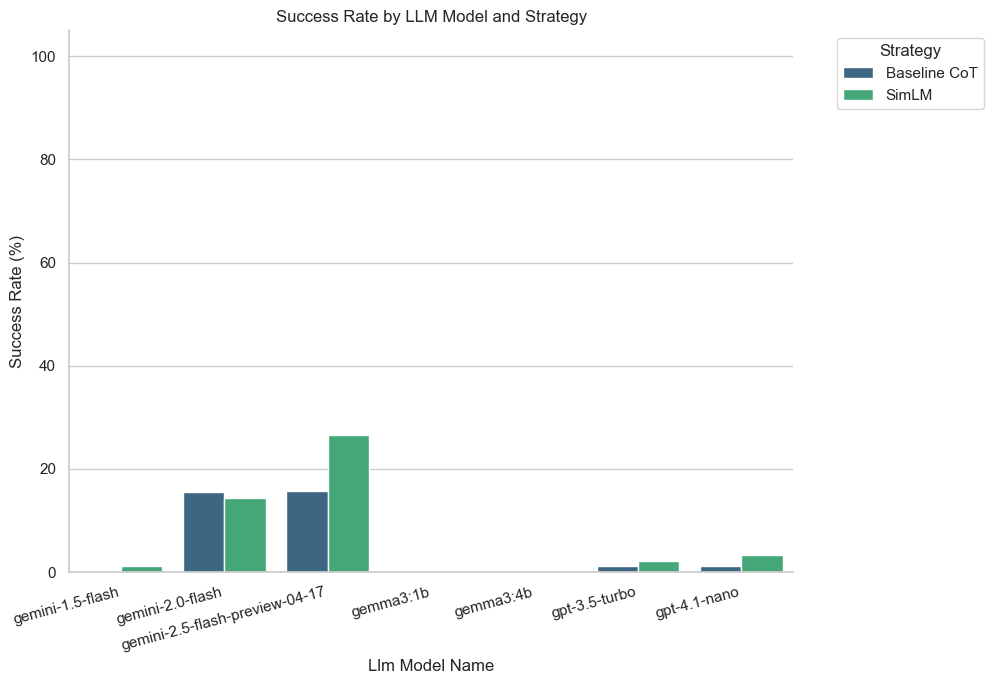

In [5]:
##### LLM Comparison #####

# Error Distribution
plot_metric_distribution(
    results_df,
    metric_col='Error',
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Error Distribution by LLM Model and Strategy',
    yscale='log'
)

# Success Rate
plot_success_rate(
    results_df,
    group_col='LLM Model Name',
    hue_col='Strategy',
    title='Success Rate by LLM Model and Strategy'
)

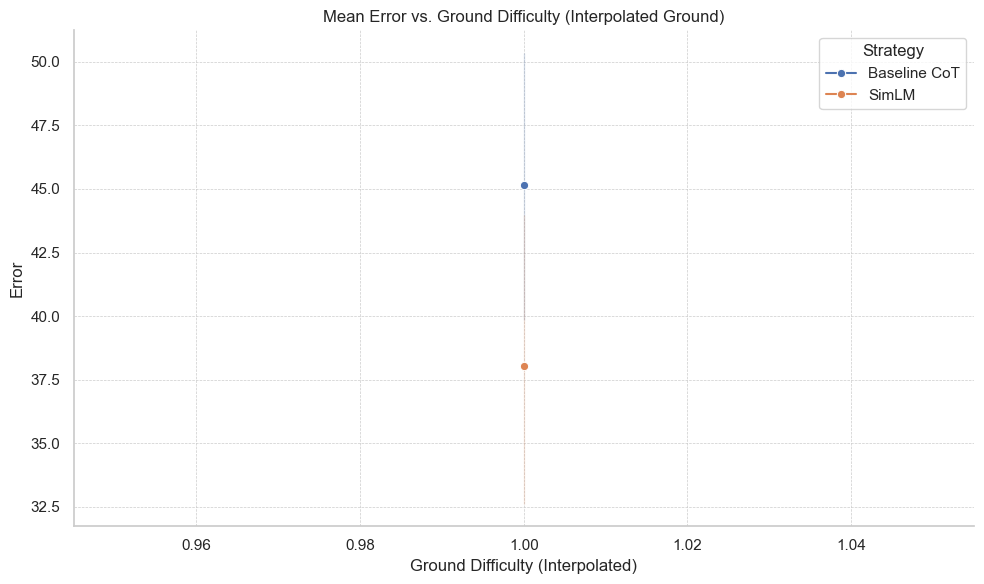

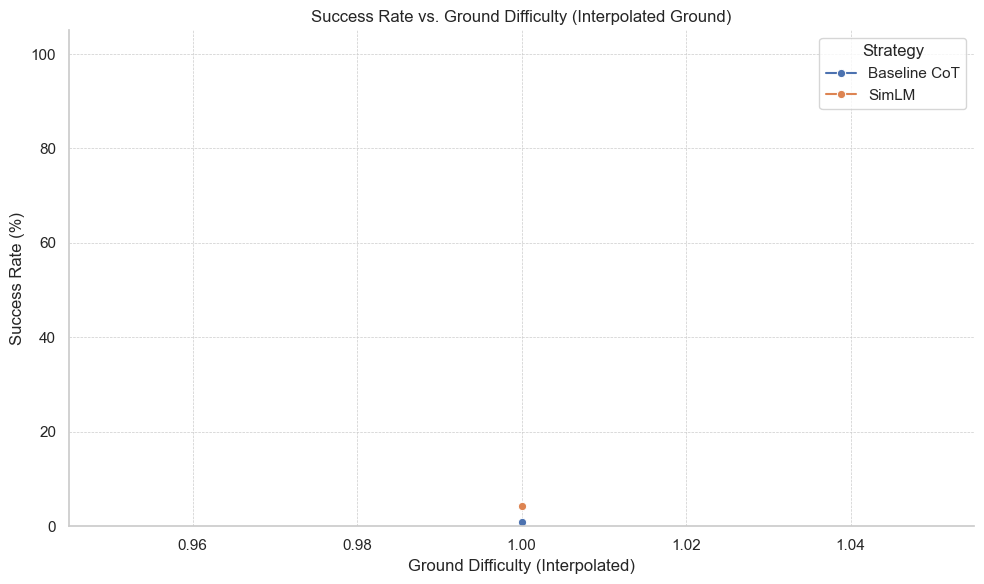

In [6]:
##### Experiment C #####

# Error vs. Difficulty
plot_metric_by_difficulty(
        results_df,
        metric_col='Error',
        title='Mean Error vs. Ground Difficulty (Interpolated Ground)'
)

# Success Rate vs. Difficulty

exp_c_df_succ = results_df[results_df['Ground Type'] == 'Interpolated'].copy()
success_by_diff = exp_c_df_succ.groupby(['Ground Difficulty', 'Strategy'], observed=False)['Success'].mean().reset_index()
success_by_diff['Success Rate (%)'] = success_by_diff['Success'] * 100

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=success_by_diff,
    x='Ground Difficulty',
    y='Success Rate (%)',
    hue='Strategy',
    marker='o'
)
plt.title('Success Rate vs. Ground Difficulty (Interpolated Ground)')
plt.xlabel("Ground Difficulty (Interpolated)")
plt.ylabel('Success Rate (%)')
plt.ylim(0, 105)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Strategy')
plt.tight_layout()
plt.show()

c:\Users\alejandro\Documents\dev\CS7643-DL-Final\simlm\analysis.py:224: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Experiment Condition', bbox_to_anchor=(1.05, 1), loc='upper left')


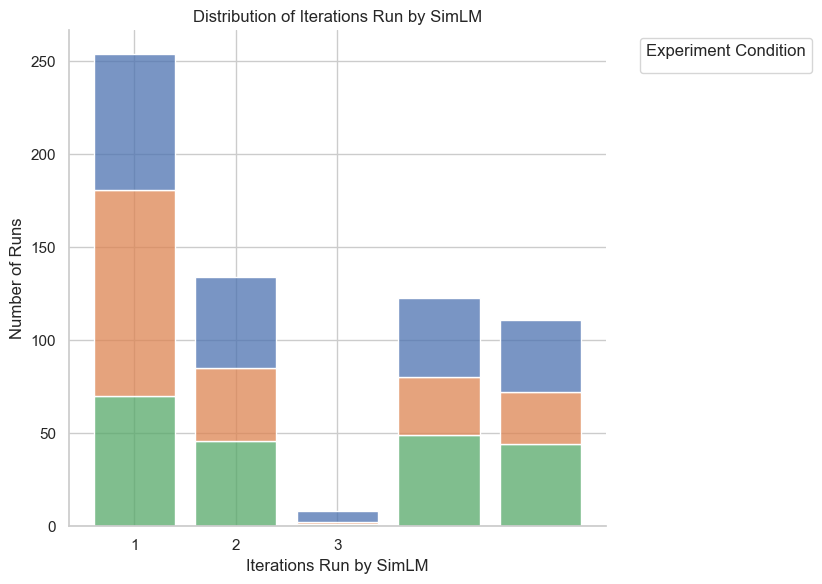

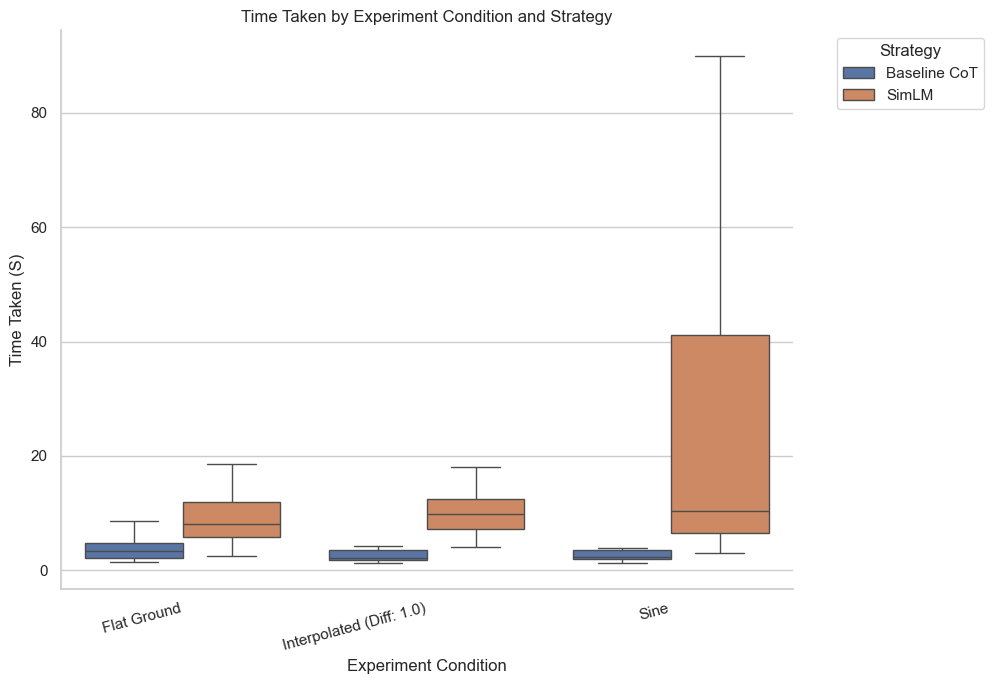

In [7]:
##### General analysis #####

# Iterations 
plot_iterations_histogram(
    results_df,
    title='Distribution of Iterations Run by SimLM'
)

# Time Taken Comparison
plot_metric_distribution(
    results_df,
    metric_col='Time Taken (s)',
    group_col='Experiment Condition',
    hue_col='Strategy',
    title='Time Taken by Experiment Condition and Strategy',
    showfliers=False 
)